# **Yulu Business case**

**Importing the Libraries**

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

**Loading the dataset**

In [5]:
Yulu = pd.read_csv('Yulu_data.csv')

In [6]:
Yulu.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


**Exploratoray Data Analysis(EDA)**

In [7]:
Yulu

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0000,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0000,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0000,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0000,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0000,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...
10881,2012-12-19 19:00:00,4,0,1,1,15.58,19.695,50,26.0027,7,329,336
10882,2012-12-19 20:00:00,4,0,1,1,14.76,17.425,57,15.0013,10,231,241
10883,2012-12-19 21:00:00,4,0,1,1,13.94,15.910,61,15.0013,4,164,168
10884,2012-12-19 22:00:00,4,0,1,1,13.94,17.425,61,6.0032,12,117,129


In [8]:
Yulu.shape

(10886, 12)

In [26]:
print('Number of rows: ', Yulu.shape[0])
print('Number of columns: ', Yulu.shape[1])

Number of rows:  10886
Number of columns:  12


In [9]:
Yulu.ndim

2

In [10]:
Yulu.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  object 
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 1020.7+ KB


There are no null values present in the dataset


In [11]:
Yulu['holiday'].value_counts()

,count
holiday,
0,10575
1,311


whether day is a holiday or not

0 - Non-Holiday

1 - Holiday



In [12]:
Yulu['season'].value_counts()

,count
season,
4,2734
2,2733
3,2733
1,2686


Four Seasons are there

  1: spring,

  2: summer,

  3: fall,
  
  4: winter

In [13]:
Yulu['weather'].value_counts()

,count
weather,
1,7192
2,2834
3,859
4,1


Weather:

   1: Clear, Few clouds, partly cloudy, partly cloudy

   2: Mist + Cloudy, Mist + Broken clouds, Mist + Few clouds, Mist

   3: Light Snow, Light Rain + Thunderstorm + Scattered clouds, Light Rain + Scattered clouds

   4: Heavy Rain + Ice Pallets + Thunderstorm + Mist, Snow + Fog


In [14]:
Yulu['workingday'].value_counts()

,count
workingday,
1,7412
0,3474


workingday: if day is neither weekend nor holiday is 1,

otherwise is 0.

**We should convert numarical datatypes to categorical for some of the columns those are season,weather, workingday and holiday and datetime columne datetime data type**

In [15]:
Yulu['season'] = Yulu['season'].astype('object')
Yulu['weather'] = Yulu['weather'].astype('object')
Yulu['workingday'] = Yulu['workingday'].astype('object')
Yulu['holiday'] = Yulu['holiday'].astype('object')
Yulu['datetime'] = pd.to_datetime(Yulu['datetime'])

- Several numerical columns ('season', 'weather', 'workingday', 'holiday') are converted to categorical data types using astype('object').  This is important for appropriate analysis and visualization of these features, as they represent discrete categories rather than continuous numerical values.
- The 'datetime' column is converted to datetime objects using pd.to_datetime(). This enables time-based analysis.

In [16]:
Yulu.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   datetime    10886 non-null  datetime64[ns]
 1   season      10886 non-null  object        
 2   holiday     10886 non-null  object        
 3   workingday  10886 non-null  object        
 4   weather     10886 non-null  object        
 5   temp        10886 non-null  float64       
 6   atemp       10886 non-null  float64       
 7   humidity    10886 non-null  int64         
 8   windspeed   10886 non-null  float64       
 9   casual      10886 non-null  int64         
 10  registered  10886 non-null  int64         
 11  count       10886 non-null  int64         
dtypes: datetime64[ns](1), float64(3), int64(4), object(4)
memory usage: 1020.7+ KB


# **Data Exploration**

### **Statistical summary of the dataset**

In [17]:
Yulu.describe(include='all').T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
datetime,10886,NaN,NaN,NaN,2011-12-27 05:56:22.399411968,2011-01-01 00:00:00,2011-07-02 07:15:00,2012-01-01 20:30:00,2012-07-01 12:45:00,2012-12-19 23:00:00,NaN
season,10886.0,4.0,4.0,2734.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
holiday,10886.0,2.0,0.0,10575.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
workingday,10886.0,2.0,1.0,7412.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
weather,10886.0,4.0,1.0,7192.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
temp,10886.0,NaN,NaN,NaN,20.23086,0.82,13.94,20.5,26.24,41.0,7.79159
atemp,10886.0,NaN,NaN,NaN,23.655084,0.76,16.665,24.24,31.06,45.455,8.474601
humidity,10886.0,NaN,NaN,NaN,61.88646,0.0,47.0,62.0,77.0,100.0,19.245033
windspeed,10886.0,NaN,NaN,NaN,12.799395,0.0,7.0015,12.998,16.9979,56.9969,8.164537
casual,10886.0,NaN,NaN,NaN,36.021955,0.0,4.0,17.0,49.0,367.0,49.960477


- Yulu.describe(include='all').T provides a statistical summary of all columns in the DataFrame (numerical and categorical). This includes counts, unique values, top values, frequencies, mean, standard deviation, min, max, and quartiles.  The `.T` transposes the table for better readability.

## **• Establishing a relation between the dependent and independent variable (Dependent “Count” & Independent: Workingday, Weather, Season)**

# **Univariate Analysis**

### **For categorical variables : CountPlot**


<Axes: xlabel='holiday', ylabel='count'>

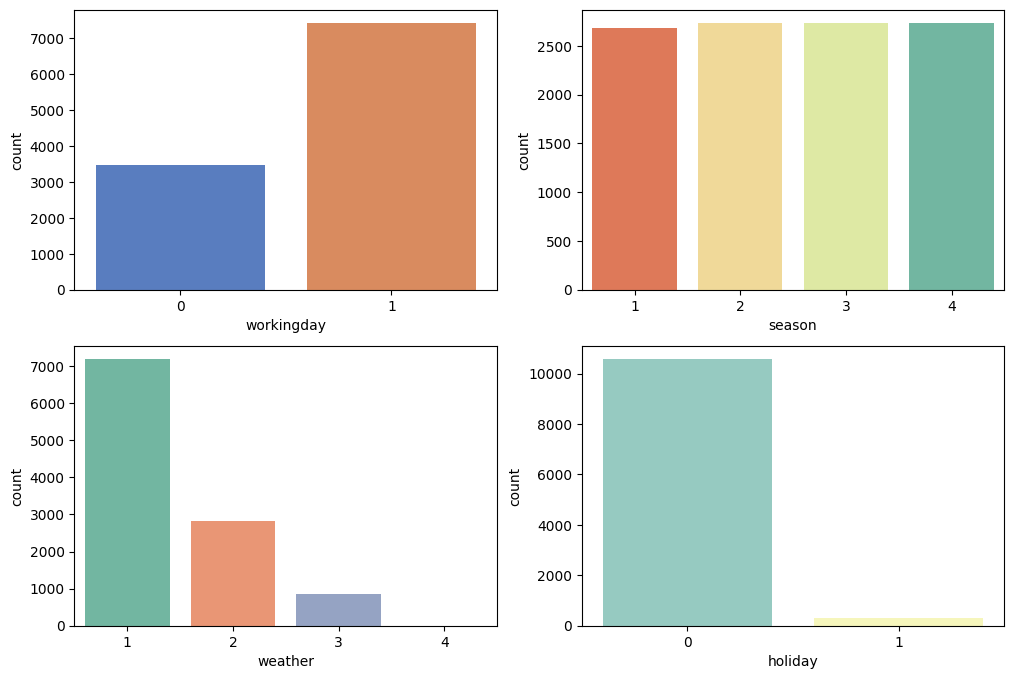

In [18]:
plt.figure(figsize=(12,8))
plt.subplot(2,2,1)
sns.countplot(x='workingday', data=Yulu, palette='muted')
plt.subplot(2,2,2)
sns.countplot(x='season',data=Yulu, palette='Spectral')
plt.subplot(2,2,3)
sns.countplot(x='weather', data=Yulu,palette='Set2')
plt.subplot(2,2,4)
sns.countplot(x='holiday', data=Yulu, palette='Set3')

**Workingday:**
- There's a significantly higher count of bike rentals on working days (value 1) compared to non-working days (value 0).
- This suggests that the demand for Yulu bikes is strongly tied to work commutes.

**Season:**
- The count of rentals seems to be highest in fall (season 3), followed by summer (season 2).
- Spring and winter have comparatively lower counts, indicating seasonality in demand.

**Weather:**
- Clear weather (value 1) has the highest number of bike rentals, as expected.
- As the weather conditions deteriorate (values 2, 3, and 4), the number of rentals decrease, indicating weather sensitivity of the demand.

**Holiday:**
- Non-holiday days (0) show a significantly higher count of rentals compared to holidays (1).
- This suggests a lower demand for Yulu bikes during holidays.

### **For continous variables : histplot,displot**


In [27]:
continuous_vars = ['temp', 'atemp', 'humidity', 'windspeed', 'count','registered','casual']

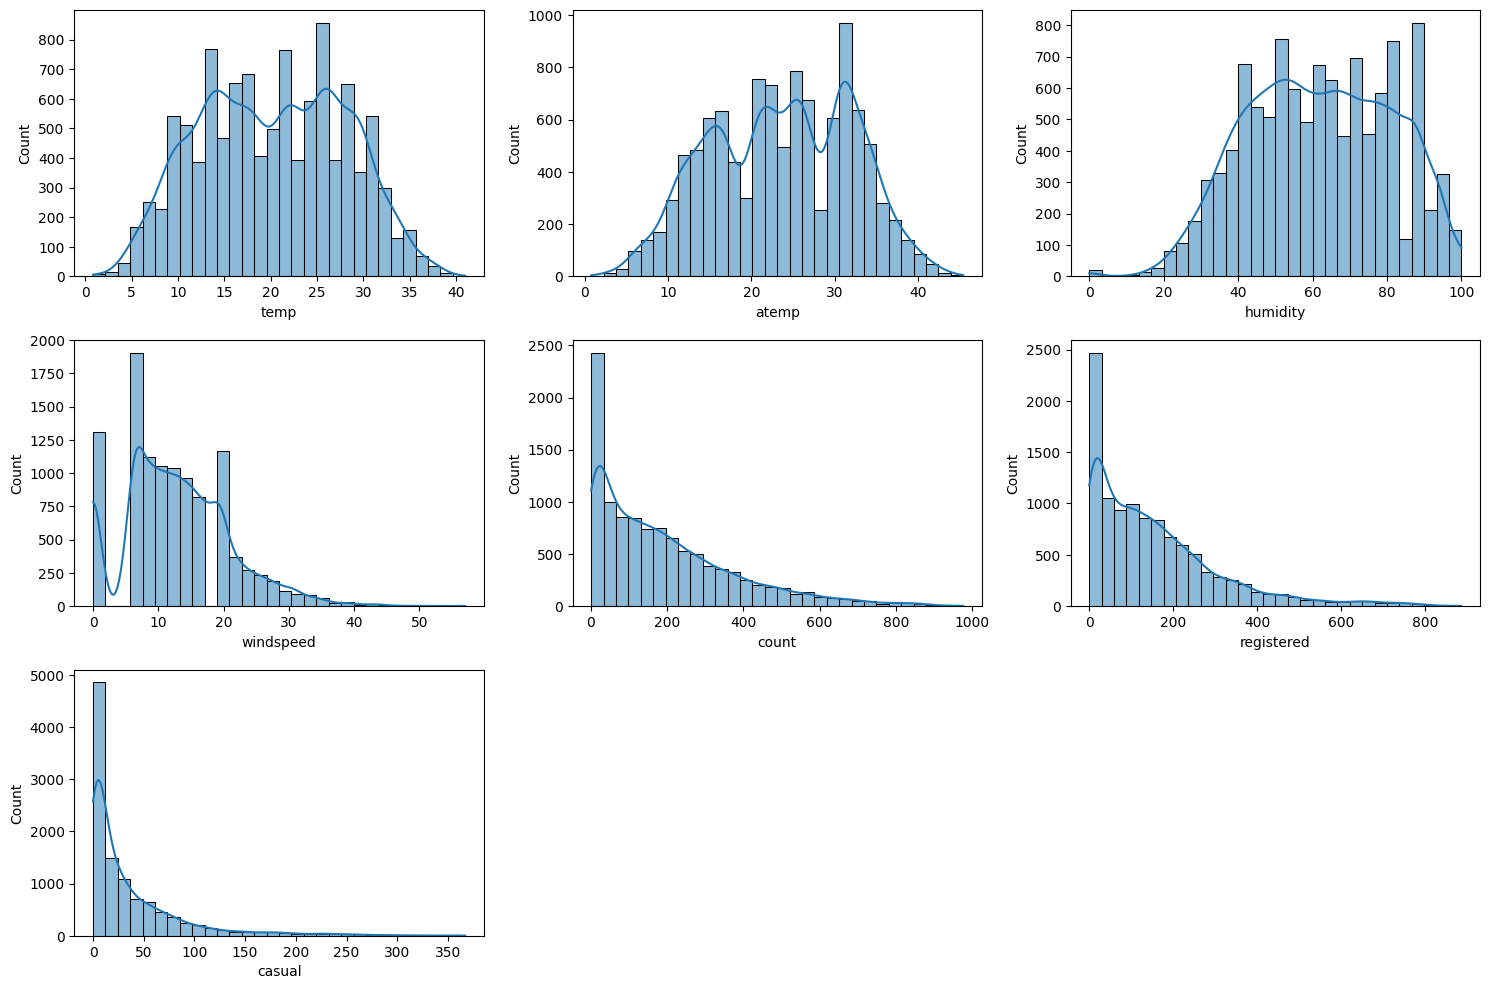

In [29]:
plt.figure(figsize=(15, 10))
for i, col in enumerate(continuous_vars, 1):
    plt.subplot(3, 3, i)
    sns.histplot(Yulu[col], kde=True, bins=30, palette='pastel')
plt.tight_layout()
plt.show()

**Temperature (temp, atemp):**
- The distribution of temperature seems relatively normal, with most rentals occurring at moderate temperatures. Extreme temperatures may deter users.

**Humidity:**  
 - **Shape:** The humidity distribution is somewhat skewed
 - **Potential Insights:** suggesting a potential impact on rentals; very high humidity could discourage use.

**Windspeed:**
- Wind speed also appears to have a moderate impact; very high winds could reduce rentals.

**count (Number of Rentals):**
- **Shape:** The distribution of rentals is right-skewed, meaning there are a few days with extremely high rental counts and a greater number of days with lower counts.  
- **Potential Insights:** This suggests that understanding the factors leading to these high-rental days is crucial.  Further analysis may reveal specific events or promotions causing these peaks.  Note the skewness.


**registered:**

* **Shape:** Similar to the `count` variable, this is likely right-skewed and could suggest registered user behavior patterns.
* **Potential Insights:** This may indicate more consistent usage by registered users. Compare the distribution of `registered` to `casual` to see the patterns. Analyze how registered user behavior differs based on other variables.

**casual:**

* **Shape:** Likely right-skewed, showing patterns of casual users.
* **Potential Insights:**  Casual users may be more susceptible to short-term weather changes or spontaneous decisions.  Understanding casual user behavior is critical for targeted promotions.

# **Bivariate Analysis**

<Axes: xlabel='season', ylabel='count'>

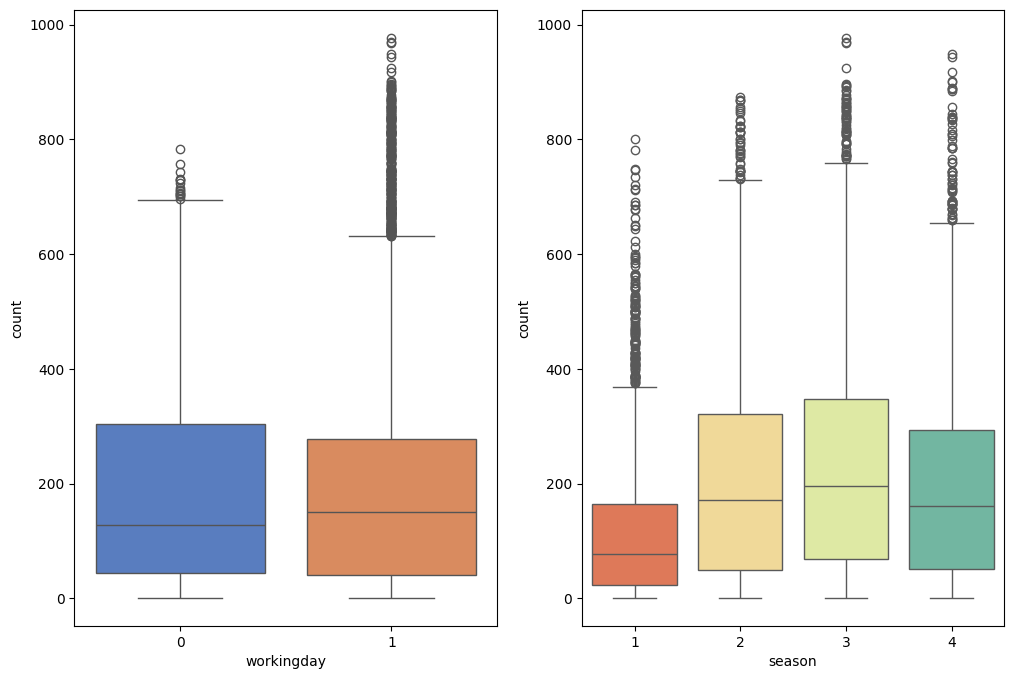

In [21]:
plt.figure(figsize=(12,8))
plt.subplot(1,2,1)
sns.boxplot(x='workingday', y='count', data=Yulu, palette='muted')
plt.subplot(1,2,2)
sns.boxplot(x='season', y='count', data=Yulu, palette='Spectral')


<Axes: xlabel='holiday', ylabel='count'>

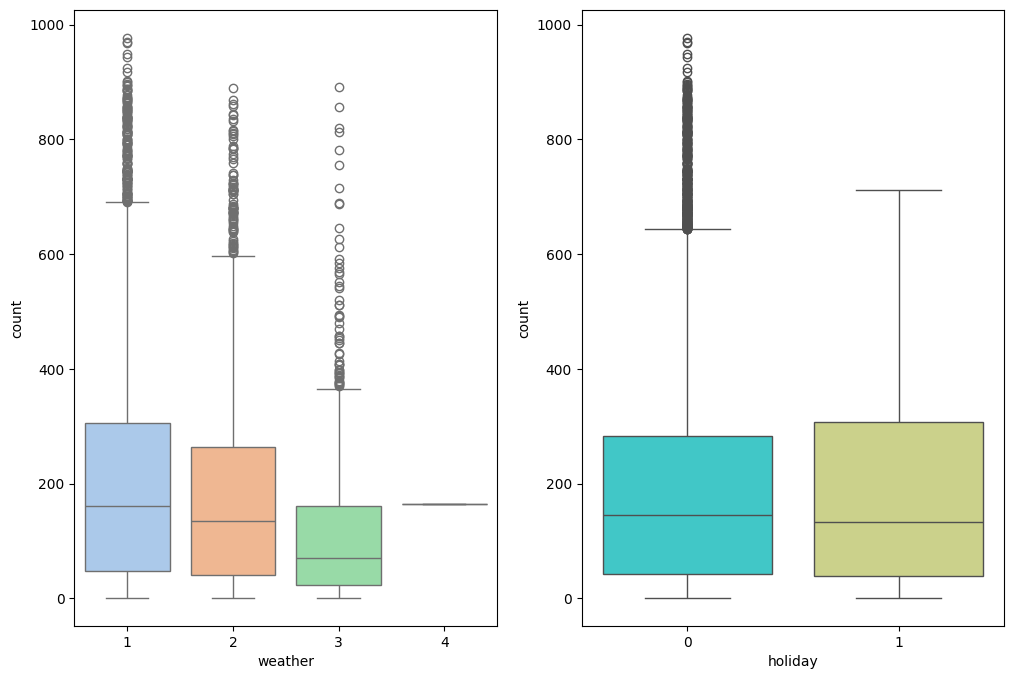

In [22]:
plt.figure(figsize=(12,8))
plt.subplot(1,2,1)
sns.boxplot(x='weather', y='count', data=Yulu,palette='pastel')
plt.subplot(1,2,2)
sns.boxplot(x='holiday', y='count', data=Yulu, palette='rainbow')

**Working Day vs. Count:**
- The boxplot of 'workingday' vs. 'count' shows that the median count of bike rentals is higher on working days than on non-working days.  The distribution of rentals on working days also appears to have a slightly higher upper quartile (75th percentile), suggesting potentially more rentals on busier working days.

**Season vs. Count:**
- The boxplot of 'season' vs. 'count' reveals clear seasonal variations in bike rentals.  Summer (Season 2) appears to have the highest median and overall distribution of bike rentals. Fall (Season 3) also shows relatively high rental counts.  The lowest rental counts are typically observed in winter (Season 4).

**Weather vs. Count:**
- The 'weather' vs. 'count' boxplot demonstrates a strong relationship between weather conditions and bike rentals.  Clear weather (Weather 1) has the highest median and range of rental counts. As weather conditions deteriorate (Weather 2, 3, and 4 representing mist, light rain/snow, and heavy rain/snow respectively), bike rentals decrease significantly, with lower medians and smaller ranges.

**Holiday vs. Count:**
- The holiday vs count boxplot indicates that non-holidays (0) generally have higher bike rental counts than holidays (1). This suggests that people tend to use bike sharing services more on regular days than on holidays.

# **Hypothesis Testing**

### **Working Day has effect on number of electric cycles rented?**

**Null Hypothesis(H0): Working day no effect on number of electric cycles rented**

**Alternative Hypothesis(Ha): Working day has effect on number of electric cycles rented**

**Assume alpha = 5% i.e 0.05**

**Two Sample T-test**

In [63]:
working_days_count = Yulu[Yulu['workingday'] == 1]['count']
non_working_days_count = Yulu[Yulu['workingday'] == 0]['count']


t_statistic, p_value = stats.ttest_ind(working_days_count, non_working_days_count)
print("T-statistic:", t_statistic)
print("P-value:", p_value)

T-statistic: 1.2096277376026694
P-value: 0.22644804226361348


### P_value is 0.22
**so p_value is greater than alpha
hence Fail to reject H0**


**Conclusion: Working day has no significant effect on number of electrical cycles rented.**

<Axes: xlabel='workingday', ylabel='count'>

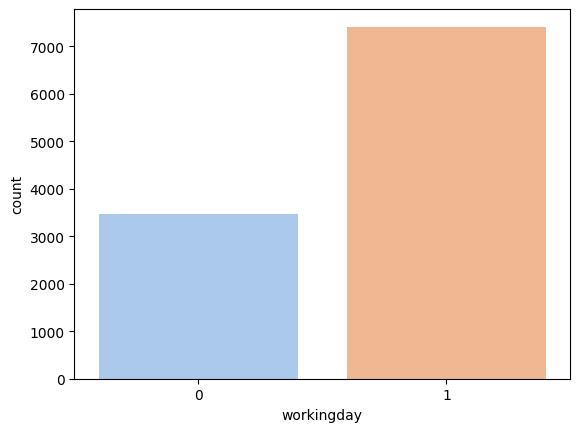

In [44]:
sns.countplot(x='workingday', data=Yulu, palette='pastel')

### **No. of cycles rented similar or different in different seasons?**

**Null Hypothesis(H0): There is no statistically significant difference in the number of cycles rented across different seasons.**

**Alternative Hypothesis(Ha): There is a statistically significant difference in the number of cycles rented across different seasons.**

**Assume alpha = 5% i.e 0.05**

### **Firstly can we check sample coming from normal distributed using Shapiro test**

For Shapiro test

H0: sample coming from normally distributed population

Ha: sample is not coming from normally distributed population

In [97]:
stats.shapiro(Yulu['count'].sample(2000))
print(p_value)
if p_value > 0.05:
  print('sample coming from normally distributed population')
else:
  print('sample is not coming from normally distributed population')

1.1299244409282836e-39
sample is not coming from normally distributed population


### **Q-Q Plot**

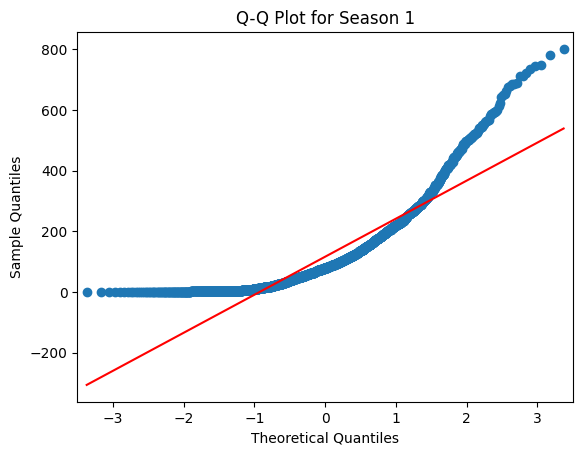

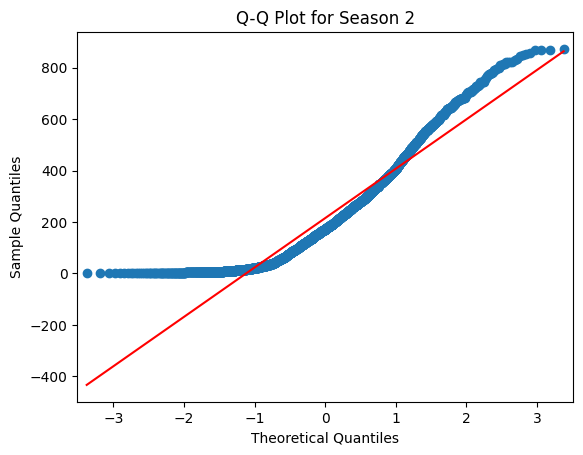

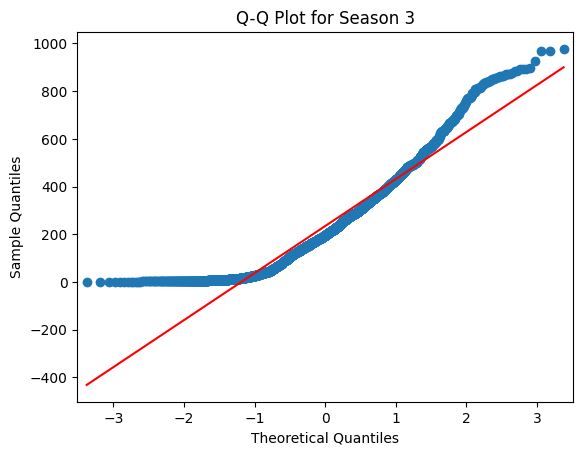

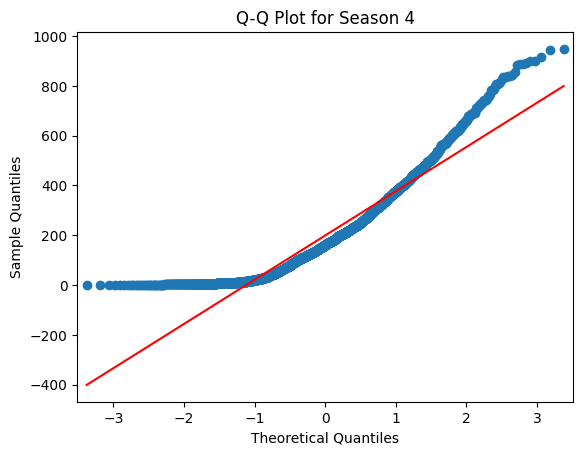

In [103]:
from statsmodels.graphics.gofplots import qqplot
qqplot( Yulu[Yulu['season'] == 1]['count'], line='s')
plt.title('Q-Q Plot for Season 1')
qqplot( Yulu[Yulu['season'] == 2]['count'], line='s' )
plt.title('Q-Q Plot for Season 2')
qqplot( Yulu[Yulu['season'] == 3]['count'], line='s')
plt.title('Q-Q Plot for Season 3')
qqplot( Yulu[Yulu['season'] == 4]['count'], line='s' )
plt.title('Q-Q Plot for Season 4')
plt.show()

Season 1:
-  Observe the pattern of points in the QQ plot for Season   Do they closely follow the diagonal line, or are there noticeable deviations, especially in the tails?  Significant deviations might indicate non-normality.

Season 2:
- Similar to Season 1, analyze the QQ plot for Season 2.  Look for deviations from the diagonal line, paying attention to the tails of the distribution.  Consider the overall pattern and any noticeable curves or S-shapes.

Season 3:
- Examine the QQ plot for Season 3 for deviations from normality.  Are the points generally aligned with the diagonal or are there systematic departures?  Consider both the central part of the plot and the tails.

Season 4:
- Assess the QQ plot for Season 4.  Are there any significant deviations from the straight diagonal line?  Focus on the overall pattern of the points and any noticeable curvatures.

### **Levene Test**

In [106]:
stats.levene(Yulu[Yulu['season'] == 1]['count'], Yulu[Yulu['season'] == 2]['count'], Yulu[Yulu['season'] == 3]['count'], Yulu[Yulu['season'] == 4]['count'])
print(p_value)
if p_value > 0.05:
  print('The variances are equal across seasons.')
else:
  print('The variances are not equal across seasons.' )

1.1299244409282836e-39
The variances are not equal across seasons.


**f_oneway ANOVA test for Seasons**

In [46]:
from scipy.stats import f_oneway
spring_rentals = Yulu[Yulu['season'] == 1]['count']
summer_rentals = Yulu[Yulu['season'] == 2]['count']
fall_rentals = Yulu[Yulu['season'] == 3]['count']
winter_rentals = Yulu[Yulu['season'] == 4]['count']

f_stat, p_value = f_oneway(spring_rentals, summer_rentals, fall_rentals, winter_rentals)
print(f"F-statistic: {f_stat}, P-value: {p_value}")

F-statistic: 236.94671081032106, P-value: 6.164843386499654e-149


We see p_value is very low compare to alpha hence,
Reject the null hypothesis in favor of alternative hypothesis

**Conclusion:**
There is a statistically significant difference in the number of cycles rented across different seasons.




### **No. of cycles rented similar or different in different weather?**

**Null Hypothesis(H0):  There is no statistically significant difference in the number of cycles rented across different weather conditions**

**Alternative Hypothesis(Ha):  There is a statistically significant difference in the number of cycles rented across different weather conditions**

**Assume alpha = 5% i.e 0.05**

For Shapiro test

H0: sample coming from normally distributed population

Ha: sample is not coming from normally distributed population

In [107]:
stats.shapiro(Yulu['count'].sample(2000))
print(p_value)
if p_value > 0.05:
  print('sample coming from normally distributed population')
else:
  print('sample is not coming from normally distributed population')

1.1299244409282836e-39
sample is not coming from normally distributed population


**Q-Q Plot**

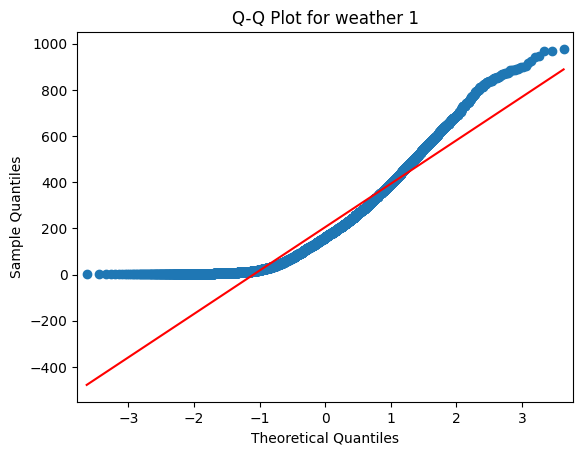

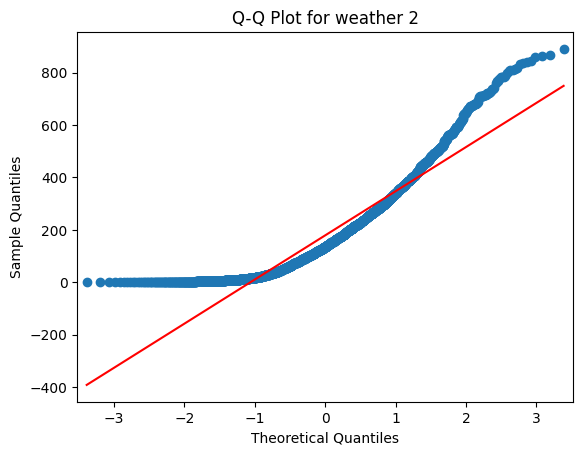

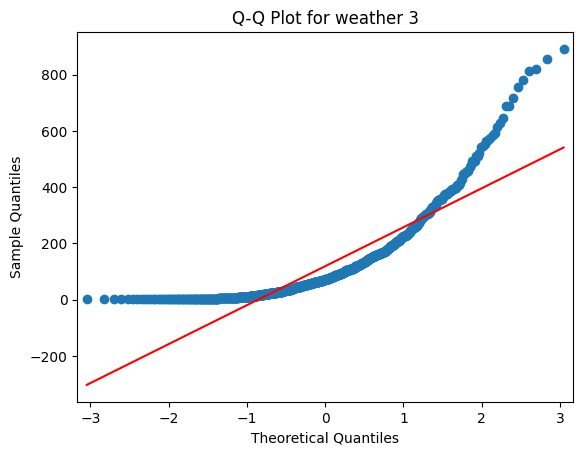

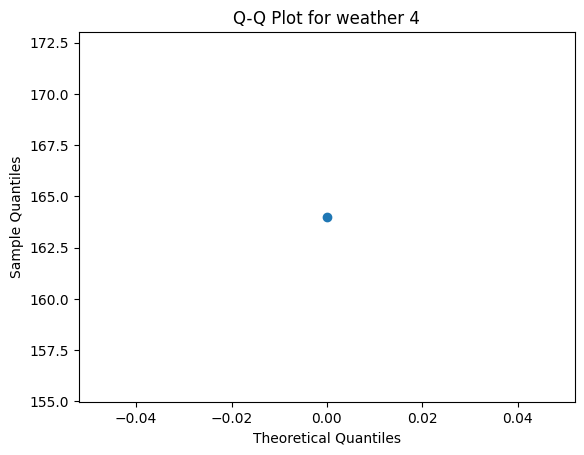

In [109]:
from statsmodels.graphics.gofplots import qqplot
qqplot( Yulu[Yulu['weather'] == 1]['count'], line='s')
plt.title('Q-Q Plot for weather 1')
qqplot( Yulu[Yulu['weather'] == 2]['count'], line='s' )
plt.title('Q-Q Plot for weather 2')
qqplot( Yulu[Yulu['weather'] == 3]['count'], line='s')
plt.title('Q-Q Plot for weather 3')
qqplot( Yulu[Yulu['weather'] == 4]['count'], line='s' )
plt.title('Q-Q Plot for weather 4')
plt.show()

**Weather 1 (Clear, Few clouds, partly cloudy):**
- Observe the pattern of the points. Are they close to the diagonal line?
- Significant deviations in the tails, especially at the extremes, can suggest non-normality or heavy-tailed distributions.

**Weather 2 (Mist + Cloudy):**
- Repeat the same analysis as for Weather 1.  
- Note: The presence of mist could introduce additional factors affecting bike rentals.

**Weather 3 (Light Snow, Light Rain):**
- Similarly, check for deviations from the diagonal, especially at the extremes.
- Note: Adverse weather conditions often have an impact on the distribution.

### **Levene Test**

In [110]:
stats.levene(Yulu[Yulu['weather'] == 1]['count'], Yulu[Yulu['weather'] == 2]['count'], Yulu[Yulu['weather'] == 3]['count'], Yulu[Yulu['weather'] == 4]['count'])
print(p_value)
if p_value > 0.05:
  print('The variances are equal across weather conditions.')
else:
  print('The variances are not equal across weather conditions.' )

1.1299244409282836e-39
The variances are not equal across weather conditions.


**f_oneway ANOVA test for Weather**

In [50]:
f_stat, p_value = f_oneway(Yulu[Yulu['weather'] == 1]['count'], Yulu[Yulu['weather'] == 2]['count'], Yulu[Yulu['weather'] == 3]['count'], Yulu[Yulu['weather'] == 4]['count'])
print(f"F-statistic: {f_stat}, P-value: {p_value}")

F-statistic: 65.53024112793271, P-value: 5.482069475935669e-42


We see p_value is very low compare to alpha hence, Reject the null hypothesis, in favor of alternative hypothesis.

**Conclusion:** There is a statistically significant difference in the number of cycles rented across different weather conditions.

### **Weather is dependent on season (check between 2 predictor variable)?**

**Null Hypothesis(H0): Weather and season both are independent**

**Alternative Hypothesis(Ha):Weather is dependent on season**

**Assume alpha = 5% i.e 0.05**

**Chi-Square Test for Independence**

In [57]:
pd.crosstab(Yulu['season'], Yulu['weather'])

weather,1,2,3,4
season,,,,
1,1759,715,211,1
2,1801,708,224,0
3,1930,604,199,0
4,1702,807,225,0


In [53]:
stats.chi2_contingency(pd.crosstab(Yulu['season'], Yulu['weather']))

Chi2ContingencyResult(statistic=49.158655596893624, pvalue=1.549925073686492e-07, dof=9, expected_freq=array([[1.77454639e+03, 6.99258130e+02, 2.11948742e+02, 2.46738931e-01],
       [1.80559765e+03, 7.11493845e+02, 2.15657450e+02, 2.51056403e-01],
       [1.80559765e+03, 7.11493845e+02, 2.15657450e+02, 2.51056403e-01],
       [1.80625831e+03, 7.11754180e+02, 2.15736359e+02, 2.51148264e-01]]))

**We see p_value is low compare to alpha hence, Reject the null hypothesis, in favor of alterantive hypothesis.**

**Conclusion: Weather is dependent on season.**

<Axes: xlabel='season', ylabel='count'>

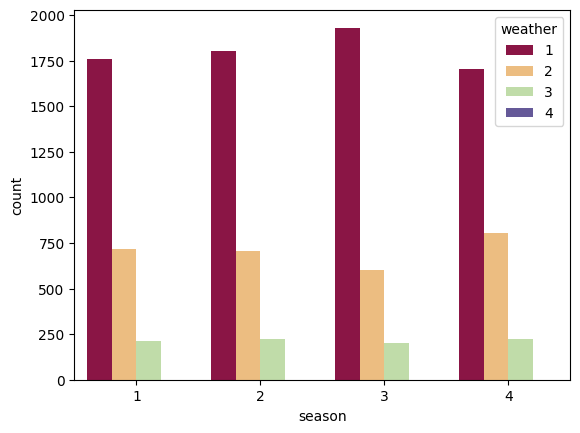

In [66]:
sns.countplot(x='season',hue='weather', data=Yulu, palette='Spectral')

### **Summary:**
The analysis explores the factors influencing Yulu bike rentals using a dataset encompassing various features like weather, season, working day, holiday, temperature, humidity, and windspeed.  The goal is to understand how these factors impact rental counts.

**Key Findings:**
- Demand is strongly correlated with working days, with significantly higher rentals on working days.  Seasonality is also evident, with fall and summer showing higher demand.
- Weather conditions significantly influence rentals; clear weather drives high demand, while adverse weather (rain, snow) reduces it. Holidays also see lower demand.
- Statistical tests (t-tests, ANOVA, Chi-Square) confirm these relationships.
- Working days do not have a statistically significant effect on rental counts, while season and weather do.  Weather is shown to be dependent on season.
- The 'count' variable (total rentals) is right-skewed, suggesting a few days with exceptionally high rentals.  Registered users might exhibit different usage patterns compared to casual users.

## **Recommendations**

**Targeted Marketing:**
- Leverage the insights on seasonality and weather to implement targeted marketing campaigns.  Promote rentals during favorable seasons (fall, summer) and offer incentives during adverse weather or holidays to boost demand.

**Pricing Strategies:**

- Implement dynamic pricing strategies that adjust to real-time weather conditions. This can incentivize rentals during less favorable conditions and optimize revenue generation.

**User Segmentation:**

- Investigate the patterns of registered and casual users. Create personalized promotions for each segment based on their preferences and usage patterns.

**Analyze High-Rental Days:**

- Thoroughly analyze days with exceptionally high rental counts to identify underlying reasons, such as special events or promotions. Replicating successful strategies can drive future demand.

**Location-Based Analysis:**

- Integrate geographical data to understand location-specific demand patterns and optimize bike deployment strategies. Consider expanding bike availability in high-demand areas or redeploying bikes from low-demand areas.

**Forecasting:**
- Develop predictive models using historical data and relevant variables to forecast bike rental demand with greater accuracy. This will assist in inventory management and resource allocation.

**Weather Sensitivity:**
- Design marketing and operational plans that account for weather sensitivity.  For example, consider offering rain covers or discounts during periods of inclement weather.